# Data Acquisition
This project uses the [Amazon Reviews '23 dataset](https://amazon-reviews-2023.github.io/index.html), which contains user reviews and product metadata across a wide range of product categories. To keep the analysis focused while still reflecting realistic recommendation scenarios, the project concentrates on three complementary domains: Electronics, Home & Kitchen, and Sports & Outdoors.

These categories were chosen because they share overlapping but non-identical attributes — such as durability, comfort, price sensitivity, and usage context — making them well suited for evaluating a conversational recommendation layer across multiple domains. At the same time, they provide rich review text and sufficient interaction density to support both content-based and collaborative models.

All categories are processed through a single, shared pipeline, with controlled sampling of users and items to ensure the project remains computationally manageable and comparable across domains.

## Downloading data

In [ ]:
!mkdir -p ../data

In [ ]:
# Download data from Hugging Face (https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) and move it to the data folder

https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/raw/meta_categories/meta_Electronics.jsonl
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/raw/review_categories/Electronics.jsonl
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/raw/meta_categories/meta_Home_and_Kitchen.jsonl
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/raw/review_categories/Home_and_Kitchen.jsonl
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/raw/meta_categories/meta_Sports_and_Outdoors.jsonl
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/raw/review_categories/Sports_and_Outdoors.jsonl

## Preprocessing items

In [3]:
import os
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT_CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / "functions").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the project root containing functions/.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from functions.io import cols_of, select_with_nulls

Before proceeding, we need to load and preprocess these datasets into a more sustainable format, such as Parquet. This will make subsequent analysis and processing much more efficient.

In [4]:
con = duckdb.connect()

con.execute("PRAGMA threads=4")
con.execute("PRAGMA preserve_insertion_order=false")
con.execute("PRAGMA temp_directory='../data/duckdb_tmp'")
con.execute("PRAGMA memory_limit='16GB'")

paths = {
    "electronics": "../data/meta_Electronics.jsonl",
    "home_and_kitchen": "../data/meta_Home_and_Kitchen.jsonl",
    "sports_and_outdoors": "../data/meta_Sports_and_Outdoors.jsonl",
}

COLUMNS = {
    "parent_asin": "VARCHAR",
    "main_category": "VARCHAR",
    "title": "VARCHAR",
    "store": "VARCHAR",
    "average_rating": "DOUBLE",
    "rating_number": "BIGINT",
    "price": "VARCHAR",
    "categories": "VARCHAR",
    "description": "VARCHAR",
    "details": "VARCHAR",
    "features": "VARCHAR",
    "images": "VARCHAR",
    "videos": "VARCHAR",
    "bought_together": "VARCHAR",
}

raw_metadata_parquet_path = "../data/raw_metadata.parquet"

In [ ]:
out_dir = "../data/raw_metadata_parts"
os.makedirs(out_dir, exist_ok=True)

!sudo ../clean_cache.sh
for source, path in paths.items():
    !sudo ../clean_cache.sh
    present = cols_of(path)
    sel = select_with_nulls(COLUMNS.keys(), present)

    out_path = f"{out_dir}/raw_metadata_{source}.parquet"

    q = f"""
  SELECT
    {", ".join(
      (col if col != "price" else "TRY_CAST(price AS DOUBLE) AS price")
      for col in COLUMNS.keys()
    )},
    '{source}' AS source
  FROM (
    SELECT {sel}
    FROM read_json('{path}', columns={COLUMNS})
  )
  """

    con.execute(f"COPY ({q}) TO '{out_path}' (FORMAT 'parquet')")

In [ ]:
!sudo ../clean_cache.sh
con.execute(
    f"""
COPY (
  SELECT * FROM read_parquet('{out_dir}/raw_metadata_*.parquet')
) TO '{raw_metadata_parquet_path}' (FORMAT 'parquet')
"""
)

In [7]:
!sudo ../clean_cache.sh
con.execute(f"SELECT * FROM read_parquet('{raw_metadata_parquet_path}') LIMIT 3").fetchdf()

,parent_asin,main_category,title,store,average_rating,rating_number,price,categories,description,details,features,images,videos,bought_together,source
0,B09W2CNCR7,Cell Phones & Accessories,Youskin Airpod 1st Generation Case Secure Lock...,Youskin,4.4,935,10.99,"[""Electronics"",""Headphones, Earbuds & Accessor...",[],"{""Package Dimensions"":""5 x 4.06 x 1.65 inches""...","[""Only compatible with Apple Airpods 1&2nd Gen...","[{""thumb"":""https://m.media-amazon.com/images/I...","[{""title"":""Valkit for Airpods 1/2/Pro/3/Pro 2 ...",None,electronics
1,B07KJDT1BX,All Electronics,RCA 25424RE1 4-Line Expandable Phone System wi...,blucoil,4.7,27,NaN,[],[],"{""Product Dimensions"":""9.64 x 9.2 x 5.3 inches...",[],"[{""thumb"":""https://m.media-amazon.com/images/I...","[{""title"":""RCA 4-Line Phone System"",""url"":""htt...",None,electronics
2,B0948Z2Q2T,All Electronics,Keyboard Cover for 2022 HP Envy x360 2-in-1 15...,CaseBuy,4.3,374,6.44,"[""Electronics"",""Computers & Accessories"",""Comp...",[],"{""Product Dimensions"":""11.54 x 4.13 x 0.12 inc...","[""【!!! Compare Your keyboard layout with IMAGE...","[{""thumb"":""https://m.media-amazon.com/images/I...","[{""title"":""How to distinguish keyboard layout?...",None,electronics


We restrict the candidate catalog to items with at least X reviews to ensure sufficient textual evidence for grounded explanations and stable item-level aggregates. This excludes extremely sparse and newly listed items; handling true item cold-start is left for future work.

Raw data: 6933017
Filtered data: 3767130


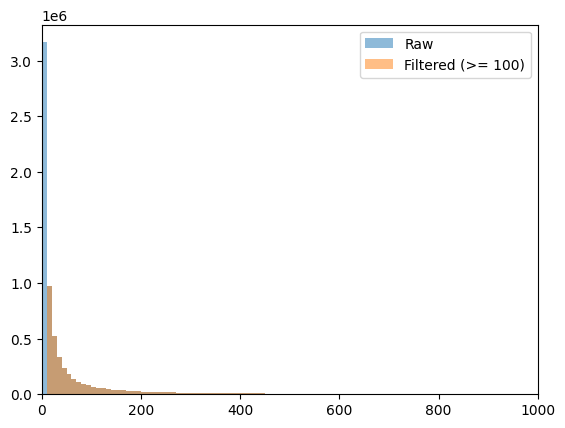

In [8]:
!sudo ../clean_cache.sh
N = 10
raw_n = con.execute(f"SELECT COUNT(*) FROM read_parquet('{raw_metadata_parquet_path}')").fetchone()[0]
filtered_n = con.execute(
    f"SELECT COUNT(*) FROM read_parquet('{raw_metadata_parquet_path}') WHERE rating_number >= {N}"
).fetchone()[0]

print(f"Raw data: {raw_n}")
print(f"Filtered data: {filtered_n}")

!sudo ../clean_cache.sh
hist_raw = con.execute(
    f"""
    SELECT
      CAST(FLOOR(LEAST(COALESCE(rating_number, 0), 1000) / 10) * 10 AS INTEGER) AS bin,
      COUNT(*) AS cnt
    FROM read_parquet('{raw_metadata_parquet_path}')
    WHERE rating_number IS NOT NULL
    GROUP BY 1
    ORDER BY 1
"""
).fetchall()

hist_filt = con.execute(
    f"""
    SELECT
      CAST(FLOOR(LEAST(COALESCE(rating_number, 0), 1000) / 10) * 10 AS INTEGER) AS bin,
      COUNT(*) AS cnt
    FROM read_parquet('{raw_metadata_parquet_path}')
    WHERE rating_number IS NOT NULL
      AND rating_number >= {N}
    GROUP BY 1
    ORDER BY 1
"""
).fetchall()

bins = np.arange(0, 1010, 10)
raw_counts = np.zeros(len(bins) - 1, dtype=np.int64)
filt_counts = np.zeros(len(bins) - 1, dtype=np.int64)

bin_to_idx = {b: i for i, b in enumerate(bins[:-1])}
for b, c in hist_raw:
    if b in bin_to_idx:
        raw_counts[bin_to_idx[b]] = c

for b, c in hist_filt:
    if b in bin_to_idx:
        filt_counts[bin_to_idx[b]] = c

plt.figure()
plt.bar(bins[:-1], raw_counts, width=10, alpha=0.5, label="Raw", align="edge")
plt.bar(bins[:-1], filt_counts, width=10, alpha=0.5, label="Filtered (>= 100)", align="edge")

plt.xlim(0, 1000)
plt.legend()
plt.show()

In [ ]:
!sudo ../clean_cache.sh
con.execute("DROP TABLE IF EXISTS stg_items;")

# Create a temporary staging table with selected and transformed fields from the raw parquet data
con.execute(
    f"""
CREATE TEMP TABLE stg_items AS
SELECT
    parent_asin,        -- Product identifier
    main_category,      -- Main product category
    title,              -- Product title/name
    store,              -- Associated store or brand
    source,             -- Source of the data

    -- Ensure ratings and count have the correct numeric data types
    CAST(average_rating AS DOUBLE) AS average_rating,
    CAST(rating_number AS BIGINT) AS rating_number,

    -- Clean price string (remove any non-numeric/non-dot characters) and cast to float
    TRY_CAST(REGEXP_REPLACE(CAST(price AS VARCHAR), '[^0-9.]', '', 'g') AS DOUBLE) AS price,

    -- Category path: if already hierarchical (contains >), retain; else, squish whitespace
    CASE
        WHEN instr(CAST(categories AS VARCHAR), '>') > 0 THEN CAST(categories AS VARCHAR)
        ELSE REGEXP_REPLACE(CAST(categories AS VARCHAR), '\\s+', ' ', 'g')
    END AS categories_path,

    -- Clean long string/text columns by squishing consecutive whitespace
    REGEXP_REPLACE(CAST(description AS VARCHAR), '\\s+', ' ', 'g') AS description_text,
    REGEXP_REPLACE(CAST(features AS VARCHAR), '\\s+', ' ', 'g') AS features_text,

    -- Count number of images in list/JSON string field, handles: null/empty/"[]"
    CASE
        WHEN images IS NULL OR CAST(images AS VARCHAR) = '' OR CAST(images AS VARCHAR) = '[]' THEN 0
        ELSE 1 + length(CAST(images AS VARCHAR)) - length(replace(CAST(images AS VARCHAR), ',', ''))
    END AS n_images,

    -- Count number of videos in list/JSON string field
    CASE
        WHEN videos IS NULL OR CAST(videos AS VARCHAR) = '' OR CAST(videos AS VARCHAR) = '[]' THEN 0
        ELSE 1 + length(CAST(videos AS VARCHAR)) - length(replace(CAST(videos AS VARCHAR), ',', ''))
    END AS n_videos,

    -- Count number of bought_together (related items) in list/JSON string field
    CASE
        WHEN bought_together IS NULL OR CAST(bought_together AS VARCHAR) = '' OR CAST(bought_together AS VARCHAR) = '[]' THEN 0
        ELSE 1 + length(CAST(bought_together AS VARCHAR)) - length(replace(CAST(bought_together AS VARCHAR), ',', ''))
    END AS n_bought_together

FROM read_parquet('{raw_metadata_parquet_path}')
WHERE rating_number >= 10; -- Filter: only include items with at least 10 reviews
"""
)

In [ ]:
!sudo ../clean_cache.sh

con.execute("DROP TABLE IF EXISTS items_dedup;")

# Create a deduplicated view of the item metadata:
#   - For each parent_asin (unique product), select the "best" row:
#        * Highest rating_number
#        * Next, highest average_rating
#        * Next, sorted by title (alphabetically)
#   - Add boolean indicators for presence of images, videos, bought_together, description and features info.
con.execute(
    """
CREATE TEMP TABLE items_dedup AS
SELECT
    parent_asin,
    main_category,
    title,
    store,
    source,
    average_rating,
    rating_number,
    price,
    categories_path,
    description_text,
    features_text,
    CAST(n_images AS INTEGER) AS n_images,
    CAST(n_videos AS INTEGER) AS n_videos,
    CAST(n_bought_together AS INTEGER) AS n_bought_together,
    (n_images > 0) AS has_images,
    (n_videos > 0) AS has_videos,
    (n_bought_together > 0) AS has_bought_together,
    (description_text IS NOT NULL AND description_text <> '[]') AS has_description,
    (features_text IS NOT NULL AND features_text <> '[]') AS has_features
FROM (
    SELECT
        *,
        -- Assign row numbers: for each parent_asin, select "best" record using tie-breakers.
        row_number() OVER (
            PARTITION BY parent_asin
            ORDER BY coalesce(rating_number, 0) DESC, coalesce(average_rating, 0) DESC, title
        ) AS rn
    FROM stg_items
)
WHERE rn = 1;  -- Only keep the best row for each parent_asin
"""
)

In [ ]:
out_path = "../data/items.parquet"

!sudo ../clean_cache.sh
con.execute(
    f"""
COPY items_dedup TO '{out_path}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""
)

In [12]:
out_path = "../data/items.parquet"

!sudo ../clean_cache.sh
con.execute(f"SELECT * FROM read_parquet('{out_path}') LIMIT 3").fetchdf()

,parent_asin,main_category,title,store,source,average_rating,rating_number,price,categories_path,description_text,features_text,n_images,n_videos,n_bought_together,has_images,has_videos,has_bought_together,has_description,has_features
0,0547337876,Books,Five Little Monkeys Play Hide and Seek (A Five...,Eileen Christelow (Author),electronics,4.8,534,7.99,"[""Electronics"",""Home Audio"",""Home Theater""]","[""Review"",""\""popular series...counting practic...","[""Mama’s out dancing, and Lulu, the babysitter...",5,0,0,True,False,False,True,True
1,0746066929,Amazon Home,That's Not My Bunny,Usborne Publishing Ltd,home_and_kitchen,4.8,2910,19.45,[],"[""Lots of baby bunnies! This brightly coloured...",[],4,0,0,True,False,False,True,False
2,0756064384,Office Products,27 Amendments Skinny Poster,Teacher's Discovery,home_and_kitchen,4.4,23,NaN,"[""Home & Kitchen"",""Wall Art"",""Posters & Prints""]","[""Display all 27 amendments to the U.S. Consti...",[],12,0,0,True,False,False,True,False


In [13]:
item_list = pd.read_parquet(out_path, columns=["parent_asin"]).drop_duplicates()["parent_asin"].tolist()
print(item_list[:10])

['B01FN2YD0W', 'B01FN6WJD6', 'B01FNEBB4Q', 'B01FNMIJIE', 'B01FNOW4QU', 'B01FNRPW5M', 'B01FNV9GUK', 'B01FO62I68', 'B01FO93ZHG', 'B01FOIV13M']


## Preprocessing reviews

In [14]:
con = duckdb.connect()

# DuckDB settings
con.execute("PRAGMA threads=4")
con.execute("PRAGMA preserve_insertion_order=false")
con.execute("PRAGMA temp_directory='../data/duckdb_tmp'")

con.execute("PRAGMA memory_limit='9GB'")

In [15]:
paths = {
    "electronics": "../data/Electronics.jsonl",
    "home_and_kitchen": "../data/Home_and_Kitchen.jsonl",
    "sports_and_outdoors": "../data/Sports_and_Outdoors.jsonl",
}

COLUMNS = {
    "rating": "DOUBLE",
    "title": "VARCHAR",
    "text": "VARCHAR",
    "images": "STRUCT(small_image_url VARCHAR, medium_image_url VARCHAR, large_image_url VARCHAR, attachment_type VARCHAR)[]",
    "asin": "VARCHAR",
    "parent_asin": "VARCHAR",
    "user_id": "VARCHAR",
    "timestamp": "BIGINT",
    "helpful_vote": "BIGINT",
    "verified_purchase": "BOOLEAN",
}

raw_data_parquet_path = "../data/raw_data.parquet"
out_dir = "../data/raw_data_parts"
os.makedirs(out_dir, exist_ok=True)

In [ ]:
!sudo ../clean_cache.sh
for source, path in paths.items():
    !sudo ../clean_cache.sh
    present = cols_of(path)
    sel = select_with_nulls(COLUMNS.keys(), present)

    out_path = f"{out_dir}/raw_data_{source}.parquet"

    q = f"""
  SELECT
    {", ".join(COLUMNS.keys())},
    '{source}' AS source
  FROM (
    SELECT {sel}
    FROM read_json('{path}', columns={COLUMNS})
  )
  """

    con.execute(f"COPY ({q}) TO '{out_path}' (FORMAT 'parquet')")

Here we also need to do as before and filter the data only for the selected products

In [ ]:
item_df = pd.DataFrame({"parent_asin": item_list})
con.register("item_list_table", item_df)

!sudo ../clean_cache.sh
con.execute(
    f"""
COPY (
  SELECT p.*
  FROM read_parquet('{out_dir}/raw_data_*.parquet') p
  SEMI JOIN item_list_table i
    ON p.parent_asin = i.parent_asin
) TO '{raw_data_parquet_path}' (FORMAT 'parquet')
"""
)

In [ ]:
!sudo ../clean_cache.sh

con.execute("DROP TABLE IF EXISTS reviews_clean;")

con.execute(
    f"""
CREATE TEMP TABLE reviews_clean AS
SELECT
    rating,
    title,
    text,
    asin,
    parent_asin,
    user_id,
    timestamp,
    helpful_vote,
    verified_purchase,
    source,

    CAST(
        CASE
            WHEN images IS NULL THEN 0
            ELSE length(images)
        END AS INTEGER
    ) AS n_images,

    CAST(
        CASE
            WHEN images IS NULL THEN FALSE
            ELSE length(images) > 0
        END AS BOOLEAN
    ) AS has_images

FROM read_parquet('{raw_data_parquet_path}');
"""
)

out_path = "../data/reviews.parquet"

!sudo ../clean_cache.sh
con.execute(
    f"""
COPY reviews_clean TO '{out_path}' (FORMAT PARQUET, COMPRESSION ZSTD);
"""
)

In [19]:
out_path = "../data/reviews.parquet"

!sudo ../clean_cache.sh
con.execute(f"SELECT * FROM read_parquet('{out_path}') LIMIT 3").fetchdf()

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,source,n_images,has_images
0,1.0,"Cheap, thin, flimsy, impossible to install wit...","If you like bubbles, get this product. I’ve in...",B00EL93M3S,B00EL93M3S,AEK5XQ63YTYZFSEK7S7AGCYXYDUQ,1557500703161,0,True,electronics,0,False
1,1.0,"Poor quality, didn’t work right out of the box",None of the standard USB plugs work at all. De...,B07MVZ5GHK,B07MVZ5GHK,AEK5XQ63YTYZFSEK7S7AGCYXYDUQ,1555299690392,1,True,electronics,0,False
2,3.0,Not for Toyota,I bought this for my 2008 Toyota Highlander ho...,B078LRSZDB,B0B4SN55CH,AEK5XQ63YTYZFSEK7S7AGCYXYDUQ,1540834374444,6,True,electronics,0,False


Now we have two parquet files available for analysis and modeling: one with information about products (items.parquet) and another containing customer reviews (reviews.parquet). These datasets will serve as the foundation for our exploratory data analysis (EDA), feature engineering, and subsequent modeling tasks.

items.parquet
- parent_asin: Unique identifier for the parent product (ASIN).
- main_category: The main product category under which the item is classified.
- title: The product's title or main description.
- store: The seller or store associated with the product.
- source: Dataset source or domain where the product was found (e.g., electronics, home_and_kitchen).
- average_rating: The mean customer rating for the product.
- rating_number: The total number of ratings received.
- price: Product price at the time of data collection.
- categories_path: List containing the hierarchical path of categories in which the product is classified.
- description_text: Main product description or text content about the product.
- features_text: List of bullet-point product features or highlights.
- n_images: Number of images available for the product.
- n_videos: Number of videos associated with the product.
- n_bought_together: Count of products frequently bought together with this item.
- has_images: Boolean indicating if the product has at least one image.
- has_videos: Boolean indicating if the product has at least one video.
- has_bought_together: Boolean indicating if there is at least one "bought together" product.
- has_description: Boolean indicating if the product has a non-empty description.
- has_features: Boolean indicating if the product has at least one feature listed.

reviews.parquet
- rating: Numeric score of the review (e.g., 1-5 stars).
- title: Short title summarizing the review.
- text: Main body of the review content.
- asin: Amazon Standard Identification Number for the reviewed item.
- parent_asin: Parent product ASIN, for cases where the review is linked to a product group.
- user_id: Unique identifier for the reviewer.
- timestamp: Unix timestamp indicating when the review was posted.
- helpful_vote: Number of helpful votes received for the review.
- verified_purchase: Boolean indicating if the review is from a verified purchase.
- source: Dataset domain or product category source (e.g., electronics).
- n_images: Number of images attached to the review.
- has_images: Boolean indicating if the review contains at least one image.